In [1]:
! pip install openai numpy scikit-learn matplotlib umap-learn datasets pacmap

zsh:1: /Volumes/Crucial X9/knowledge-gaps/.venv/bin/pip: bad interpreter: /Users/shreyanakum/Documents/knowledge-gaps/.venv/bin/python: no such file or directory

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip3.9 install --upgrade pip


In [2]:
from openai import OpenAI
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_samples, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import pacmap
import random
random.seed(42)
import time

ds = load_dataset("ShadenA/MathNet", "all")

/Volumes/Crucial X9/knowledge-gaps/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(ds['train'])

Dataset({
    features: ['id', 'problem_markdown', 'solutions_markdown', 'images', 'country', 'competition', 'topics_flat', 'language', 'problem_type', 'final_answer'],
    num_rows: 27817
})


In [4]:
client = OpenAI()

print(len(ds['train']))

texts = ds['train']['problem_markdown']
colors_level = ds['train']['language']

# Split into batches of 2048 and collect all embeddings
batch_size = 100  # Reduced from 2048
batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]

result = []
for i, batch in enumerate(batches):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=batch,
    )
    result.extend([np.array(item.embedding) for item in response.data])
    
    print(f"Processed batch {i+1}/{len(batches)} ({len(result)} embeddings so far)")
    time.sleep(0.5)  # Small delay to avoid rate limiting

embeddings_matrix = np.array(result)
similarity_matrix = cosine_similarity(embeddings_matrix)

# for i, text1 in enumerate(texts):
#     for j in range(i + 1, len(texts)):
#         text2 = texts[j]
#         similarity = similarity_matrix[i, j]
#         print(f"Similarity between '{text1}' and '{text2}': {similarity:.4f}")

27817
Processed batch 1/279 (100 embeddings so far)
Processed batch 2/279 (200 embeddings so far)
Processed batch 3/279 (300 embeddings so far)
Processed batch 4/279 (400 embeddings so far)
Processed batch 5/279 (500 embeddings so far)
Processed batch 6/279 (600 embeddings so far)
Processed batch 7/279 (700 embeddings so far)
Processed batch 8/279 (800 embeddings so far)
Processed batch 9/279 (900 embeddings so far)
Processed batch 10/279 (1000 embeddings so far)
Processed batch 11/279 (1100 embeddings so far)
Processed batch 12/279 (1200 embeddings so far)
Processed batch 13/279 (1300 embeddings so far)
Processed batch 14/279 (1400 embeddings so far)
Processed batch 15/279 (1500 embeddings so far)
Processed batch 16/279 (1600 embeddings so far)
Processed batch 17/279 (1700 embeddings so far)
Processed batch 18/279 (1800 embeddings so far)
Processed batch 19/279 (1900 embeddings so far)
Processed batch 20/279 (2000 embeddings so far)
Processed batch 21/279 (2100 embeddings so far)
Proc

### UMAP

In [5]:
# unique_types = list(set(colors_type))  # colors_level # colors_type
# color_map = {type_name: i for i, type_name in enumerate(unique_types)}
# color_values = [color_map[c] for c in colors_type]  # colors_level # colors_type

# reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=2, min_dist=0.1, init='random')
# embeddings_2d = reducer.fit_transform(embeddings_matrix)

# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=color_values, s=50, alpha=0.3, cmap='tab10')

# for i, txt in enumerate(texts):
#     plt.annotate(txt[:0], (embeddings_2d[i, 0], embeddings_2d[i, 1]))

# plt.xlabel('UMAP Dimension 1')
# plt.ylabel('UMAP Dimension 2')
# plt.title('UMAP Visualization of MATH Problems Dataset on OpenAI Embedding Model')
# handles = [plt.Line2D([0], [0], marker='o', color='w', 
#                       markerfacecolor=plt.cm.tab10(color_map[t]), 
#                       markersize=10, label=t) 
#            for t in unique_types]
# plt.legend(handles=handles, title='Problem Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.savefig("./umap_colors_level.png")

### PaCMAP

In [6]:
np.shape(embeddings_matrix)

(27817, 1536)

Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!


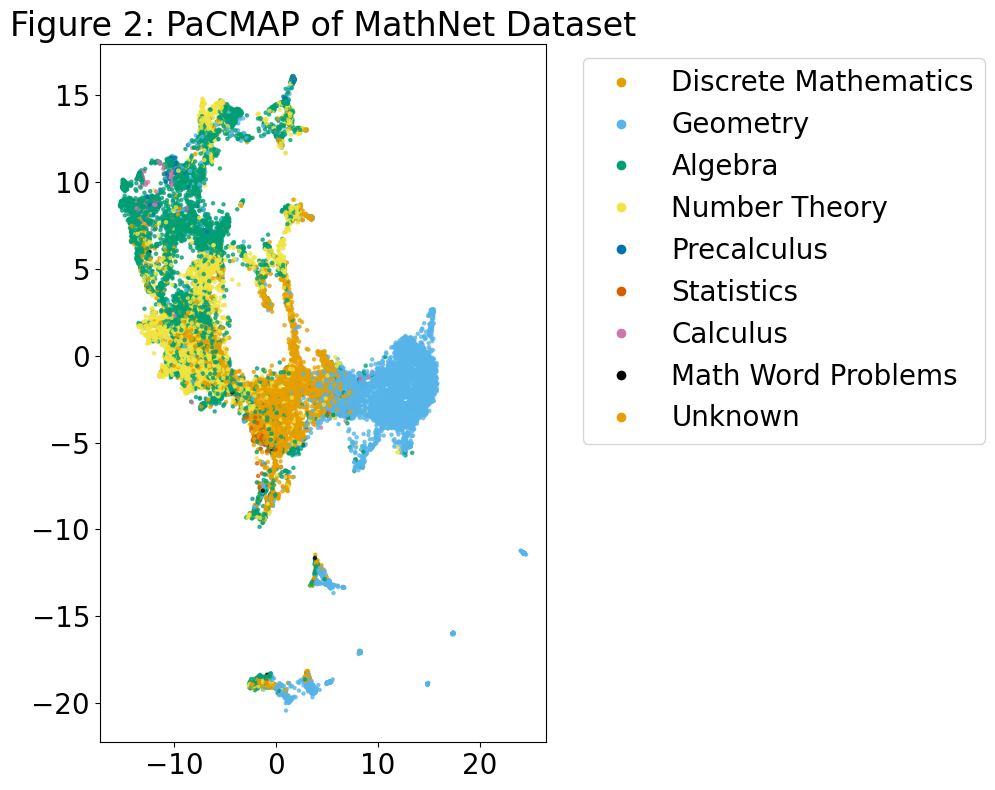

In [11]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pacmap

X = embeddings_matrix.astype(np.float32)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

pca = PCA(n_components=50, random_state=42)
X_reduced = pca.fit_transform(X).astype(np.float32)

n_neighbors = 10
nn = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean', n_jobs=-1)
nn.fit(X_reduced)
distances, indices = nn.kneighbors(X_reduced)

pair_neighbors = np.column_stack([
    np.repeat(np.arange(len(X_reduced)), n_neighbors),
    indices[:, 1:].ravel()
]).astype(np.int32)

embedding = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    MN_ratio=0.5,
    FP_ratio=2.0,
    apply_pca=False,
    random_state=42
)

embedding.pair_neighbors = pair_neighbors
X_transformed = embedding.fit_transform(X_reduced, init="pca")

OKABE_ITO = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#000000"
]

topics_raw = ds['train']['topics_flat']

def first_level_topic(x):
    if isinstance(x, list):
        x = x[0] if len(x) > 0 else "Unknown"
    x = str(x)
    return x.split(" > ")[0].strip()

def last_level_topic(x):
    if isinstance(x, list):
        x = x[0] if len(x) > 0 else "Unknown"
    x = str(x)
    return x.rsplit(" > ", 1)[-1].strip()

first_topics = [first_level_topic(x) for x in topics_raw]
last_topics = [last_level_topic(x) for x in topics_raw]

def plot_by_labels(ax, labels, title):
    unique_labels = list(dict.fromkeys(labels))
    color_map = {t: OKABE_ITO[i % len(OKABE_ITO)] for i, t in enumerate(unique_labels)}
    point_colors = [color_map[t] for t in labels]

    ax.scatter(X_transformed[:, 0], X_transformed[:, 1], c=point_colors, s=5, alpha=0.7)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color_map[t],
                   markersize=8, label=t)
        for t in unique_labels
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)
    ax.set_title(f"Figure 2: PaCMAP of MathNet Dataset", fontsize=24)
    ax.tick_params(labelsize=20)

fig, axes = plt.subplots(1, 1, figsize=(10, 8))
plot_by_labels(axes, first_topics, "Primary Topic")
# plot_by_labels(axes[1], first_topics, "First Topic")
plt.tight_layout()
plt.show()

## How good are each cluster based on their type?

* mean_silhouette = how well-separated that topic type is from all others. Scores near +1 mean problems of this type cluster cleanly away from other types; scores near 0 or negative mean they bleed into neighboring topics in embedding space.

* intra_cosine_sim = how internally cohesive the cluster is. High values mean problems of this type are semantically similar to each other. You can have high intra-cosine but low silhouette if another cluster is just as cohesive and nearby.

* db_global = a single summary score for the whole partition. Lower is better; useful for comparing if you later experiment with different embedding models or dimensionality reduction settings.

https://www.geeksforgeeks.org/machine-learning/clustering-metrics/

In [8]:
from sklearn.metrics import silhouette_samples, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

topics_raw = ds['train']['topics_flat']

def extract_first_topic(x):
    if isinstance(x, list):
        x = x[0] if len(x) > 0 else "Unknown"
    x = str(x)
    return x.split(" > ")[0].strip()

def extract_last_topic(x):
    if isinstance(x, list):
        x = x[0] if len(x) > 0 else "Unknown"
    x = str(x)
    return x.rsplit(" > ", 1)[-1].strip()

first_topics = [extract_first_topic(x) for x in topics_raw]
last_topics = [extract_last_topic(x) for x in topics_raw]

def compute_metrics(X, labels_text, label_name):
    unique_types = list(dict.fromkeys(labels_text))
    label_to_int = {t: i for i, t in enumerate(unique_types)}
    labels = np.array([label_to_int[t] for t in labels_text])

    sil_samples = silhouette_samples(X, labels, metric="cosine")
    db_global = davies_bouldin_score(X, labels)
    print(f"{label_name} Global Davies-Bouldin index: {db_global}")

    rows = []
    for t in unique_types:
        mask = np.array(labels_text) == t
        cluster_embeddings = X[mask]

        mean_sil = sil_samples[mask].mean()

        if len(cluster_embeddings) > 1:
            sim_matrix = cosine_similarity(cluster_embeddings)
            n = len(cluster_embeddings)
            upper_tri = sim_matrix[np.triu_indices(n, k=1)]
            intra_cosine = upper_tri.mean()
        else:
            intra_cosine = float("nan")

        rows.append({
            "topic_type": t,
            "n_samples": int(mask.sum()),
            "mean_silhouette": round(float(mean_sil), 4),
            "intra_cosine_sim": round(float(intra_cosine), 4),
        })

    df_metrics = pd.DataFrame(rows).sort_values("mean_silhouette", ascending=False)
    print(f"\n{label_name} metrics:")
    print(df_metrics.to_string(index=False))
    return df_metrics, db_global

df_metrics_first, db_first = compute_metrics(X, first_topics, "First topic")
df_metrics_last, db_last = compute_metrics(X, last_topics, "Last topic")

First topic Global Davies-Bouldin index: 4.3843423961010295

First topic metrics:
          topic_type  n_samples  mean_silhouette  intra_cosine_sim
            Geometry       8313           0.2233            0.4512
            Calculus        163           0.1059            0.4409
          Statistics        244           0.0590            0.3738
         Precalculus        128           0.0289            0.3966
       Number Theory       5195           0.0067            0.4158
             Unknown          1           0.0000               NaN
             Algebra       7859          -0.0458            0.3672
Discrete Mathematics       5864          -0.0585            0.3275
  Math Word Problems         50          -0.0979            0.2361
Last topic Global Davies-Bouldin index: 7.100254671056775

Last topic metrics:
                                                                                    topic_type  n_samples  mean_silhouette  intra_cosine_sim
                            